# 07 — Build final airwave analysis products

Build fixed waveform segments and pulse-morphology measurements for the
authoritative 153-event catalogue established by Notebook 04. This notebook
does **not** reconstruct or redefine the event catalogue.

Pressure traces use the canonical 1.0 s moving-median baseline-corrected Stream
written by Notebook 02; seismic traces are unchanged by that preprocessing.


## Processing history

The workflow began with manual candidate-airwave picking in Antelope `dbpick`.
The original picks were recovered from MATLAB/GISMO with millisecond precision.
Legacy 153- and 157-event catalogues were compared, differential-delay
correction was introduced, filtering and local-linear baseline experiments were
tested, and a centered 1.0 s moving median was adopted for unfiltered pressure
measurements. The assumed 351 m/s speed is only an initial alignment model.
The simple compression–rarefaction measurement is a morphology diagnostic, not an event-existence test. A tightly associated multi-channel candidate is retained even when a complex waveform—most notably the principal explosion—does not contain a qualifying positive-then-negative pair.


## 1. Imports and paths

In [1]:
from pathlib import Path
from collections.abc import Mapping
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import Stream, Trace, UTCDateTime, read

project_root = Path.cwd().resolve()
if project_root.name == "notebooks2":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

ANALYSIS_CONFIG_FILE = config.OUTPUT_DIR / "02_analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.OUTPUT_DIR / "03_weather_acoustic_summary.csv"
FINAL_CATALOGUE_FILE = config.OUTPUT_DIR / "04_final_153_event_catalogue.csv"
PICK_ASSIGNMENT_FILE = config.OUTPUT_DIR / "04_reduced_time_pick_assignments.csv"

OUTPUT_DIR = config.OUTPUT_DIR / "candidate_airwave_preparation"
EVENT_STREAM_DIR = OUTPUT_DIR / "event_streams"
FIGURE_DIR = OUTPUT_DIR / "figures"
DERIVED_OUTPUT_DIR = OUTPUT_DIR / "derived"

for directory in [
    OUTPUT_DIR,
    EVENT_STREAM_DIR,
    FIGURE_DIR,
    DERIVED_OUTPUT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


## 2. Configuration

In [2]:
for required_file in [
    ANALYSIS_CONFIG_FILE,
    WEATHER_SUMMARY_FILE,
    FINAL_CATALOGUE_FILE,
    PICK_ASSIGNMENT_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(required_file)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())

INFRASOUND_CHANNELS = tuple(analysis_config["pressure_channels"])
SEISMIC_CHANNELS = tuple(analysis_config["seismic_channels"])

noncanonical_channels = [
    channel
    for channel in (*INFRASOUND_CHANNELS, *SEISMIC_CHANNELS)
    if not channel.startswith("D")
]
if noncanonical_channels:
    raise ValueError(
        "Notebook 02 configuration contains noncanonical channel codes; "
        f"expected D* channels only, found {noncanonical_channels}"
    )
GEOMETRY_FILE = Path(
    analysis_config["geometry_file"]
).expanduser()
if not GEOMETRY_FILE.exists():
    raise FileNotFoundError(
        "Geometry product recorded by Notebook 02 was not found: "
        f"{GEOMETRY_FILE}"
    )
geometry = pd.read_csv(GEOMETRY_FILE)
weather_summary = pd.read_csv(WEATHER_SUMMARY_FILE).iloc[0]

baseline_products = analysis_config.get("baseline_removed_streams", {})
BASELINE_REMOVED_STREAM_FILE = Path(
    baseline_products.get(
        "pickle",
        config.DERIVED_DIR
        / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()
if not BASELINE_REMOVED_STREAM_FILE.exists():
    raise FileNotFoundError(
        "Run Notebook 02 to create the canonical baseline-corrected Stream: "
        f"{BASELINE_REMOVED_STREAM_FILE}"
    )

BCHH_INFRASOUND_DISTANCES_M = (
    geometry.loc[geometry["channel"].isin(INFRASOUND_CHANNELS)]
    .set_index("channel")["distance_m"]
    .astype(float)
    .to_dict()
)
REFERENCE_CHANNEL = str(analysis_config["infrasound_reference_channel"])
PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS = float(
    weather_summary["effective_sound_speed_mps"]
)

ASSOCIATION_WINDOW_S = 0.040
MINIMUM_CHANNEL_COUNT = 2

MINIMUM_POSITIVE_NEGATIVE_LAG_S = 0.010
MAXIMUM_POSITIVE_NEGATIVE_LAG_S = 0.180
PEAK_SEARCH_WINDOW_S = (-0.04, 0.25)
BOUNDARY_EXTENSION_FRACTION = 0.50

REFINE_BOUNDARIES_TO_NOISE = True
NOISE_WINDOW_S = (-0.40, -0.10)
BOUNDARY_NOISE_MULTIPLIER = 2.0
BOUNDARY_CONSECUTIVE_SAMPLES = 3
MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S = 0.12

SAVED_SEGMENT_PRE_S = 0.20
SAVED_SEGMENT_POST_S = 0.30

TIGHT_PICK_SPAN_S = 0.020
HIGH_SNR_THRESHOLD = 8.0
MODERATE_SNR_THRESHOLD = 4.0

WRITE_EVENT_PNGS = True


## 3. Load data

In [3]:
st_baseline_removed = read(
    str(BASELINE_REMOVED_STREAM_FILE),
    format="PICKLE",
)
final_catalogue = pd.read_csv(FINAL_CATALOGUE_FILE)
production_assignments = pd.read_csv(PICK_ASSIGNMENT_FILE)

required_catalogue_columns = {
    "final_event_number",
    "reconstructed_event_number",
    "reduced_event_epoch_s",
}
missing = required_catalogue_columns.difference(final_catalogue.columns)
if missing:
    raise KeyError(f"Notebook 04 final catalogue lacks {sorted(missing)}")

candidate_events = final_catalogue.copy()
candidate_events["candidate_event_number"] = (
    candidate_events["final_event_number"].astype(int)
)

# Map the authoritative Notebook 04 pick assignments onto final event numbers.
event_number_map = final_catalogue[
    ["reconstructed_event_number", "final_event_number"]
].copy()

assigned_picks = production_assignments.loc[
    production_assignments["association_status"].eq("associated")
].copy()
assigned_picks = assigned_picks.merge(
    event_number_map,
    on="reconstructed_event_number",
    how="inner",
    validate="many_to_one",
)
assigned_picks["candidate_event_number"] = (
    assigned_picks["final_event_number"].astype(int)
)

candidate_events = candidate_events.sort_values(
    "candidate_event_number"
).reset_index(drop=True)
assigned_picks = assigned_picks.sort_values(
    ["candidate_event_number", "reduced_pick_epoch_s"]
).reset_index(drop=True)

print(st_baseline_removed)
print("Notebook 04 final events:", len(candidate_events))
print("Associated picks for retained events:", len(assigned_picks))


6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Notebook 04 final events: 153
Associated picks for retained events: 369


## 4. Use the canonical Notebook 02 baseline-corrected Stream

The moving-median correction is applied once, upstream in Notebook 02.
Notebook 06 validates that adopted preprocessing. No baseline filter is
reimplemented here.


In [4]:
# The canonical baseline-corrected Stream was loaded above.
# Assert that it contains the expected analysis channels.
stream_channels = [tr.stats.channel for tr in st_baseline_removed]
missing_channels = (
    set(INFRASOUND_CHANNELS) | set(SEISMIC_CHANNELS)
) - set(stream_channels)
if missing_channels:
    raise KeyError(
        "Notebook 02 baseline Stream lacks expected channels: "
        f"{sorted(missing_channels)}"
    )


## 5. Adopt Notebook 04 reduced-time pick assignments

Notebook 04 already applies the provisional differential-delay correction and
defines the retained 153-event catalogue. Those assignments are authoritative
here; repeating association would create a second, potentially divergent
catalogue.


In [5]:
reference_distance_m = BCHH_INFRASOUND_DISTANCES_M[REFERENCE_CHANNEL]
DIFFERENTIAL_DELAYS_S = {
    channel: (
        BCHH_INFRASOUND_DISTANCES_M[channel] - reference_distance_m
    ) / PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS
    for channel in INFRASOUND_CHANNELS
}

print("Reference channel:", REFERENCE_CHANNEL)
print("Effective acoustic speed:", PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS)
print("Differential delays (s):", DIFFERENTIAL_DELAYS_S)


Reference channel: DD2
Effective acoustic speed: 350.97693348367756
Differential delays (s): {'DD1': 0.09010670165049936, 'DD2': 0.0, 'DD3': 0.01286658283859636}


## 6. Verify retained-event pick support


In [6]:
support = (
    assigned_picks
    .groupby("candidate_event_number")
    .agg(
        assigned_pick_count=("pickIndex", "size"),
        assigned_channel_count=("association_channel", "nunique"),
        assigned_pick_span_s=(
            "reduced_pick_epoch_s",
            lambda values: float(values.max() - values.min()),
        ),
    )
    .reset_index()
)

candidate_events = candidate_events.merge(
    support,
    on="candidate_event_number",
    how="left",
    validate="one_to_one",
)

if candidate_events["candidate_event_number"].duplicated().any():
    raise ValueError("Duplicate final event numbers after Notebook 04 handoff")
if len(candidate_events) != 153:
    raise RuntimeError(
        f"Expected 153 retained events from Notebook 04; found {len(candidate_events)}"
    )

print(candidate_events["assigned_channel_count"].value_counts().sort_index())
display(candidate_events.head())


assigned_channel_count
2    90
3    63
Name: count, dtype: int64


,reconstructed_event_number,reduced_event_epoch_s,first_reduced_pick_epoch_s,last_reduced_pick_epoch_s,corrected_pick_span_s,pick_count,channel_count,channels,pick_indices,observed_first_pick_epoch_s,...,observed_last_pick_time,catalogue_decision,decision_basis,dd2_dd3_best_correlation,robust_stack_peak_snr,final_event_number,candidate_event_number,assigned_pick_count,assigned_channel_count,assigned_pick_span_s
0,1,1.472735e+09,1.472735e+09,1.472735e+09,0.002107,3,3,"DD1,DD2,DD3","198,193,194",1.472735e+09,...,2016-09-01 13:07:16.016000032+00:00,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,1,1,3,3,0.002107
1,2,1.472735e+09,1.472735e+09,1.472735e+09,0.011107,3,3,"DD1,DD2,DD3","201,199,200",1.472735e+09,...,2016-09-01 13:07:16.145999908+00:00,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,2,2,3,3,0.011107
2,3,1.472735e+09,1.472735e+09,1.472735e+09,0.003760,3,3,"DD1,DD2,DD3","204,202,203",1.472735e+09,...,2016-09-01 13:07:16.345999956+00:00,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,3,3,3,3,0.003760
3,4,1.472735e+09,1.472735e+09,1.472735e+09,0.029866,2,2,"DD2,DD3","206,205",1.472735e+09,...,2016-09-01 13:07:16.461999893+00:00,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,4,4,2,2,0.029866
4,5,1.472735e+09,1.472735e+09,1.472735e+09,0.000866,2,2,"DD2,DD3","207,208",1.472735e+09,...,2016-09-01 13:07:16.812000036+00:00,retain,at least two reduced-time-associated infrasoun...,NaN,NaN,5,5,2,2,0.000866


## 7. Shift waveform timing to the DD2 reference

In [7]:
def select_one_trace(stream: Stream, channel: str) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {len(matches)}"
        )
    return matches[0]


def shift_trace_to_reference(trace: Trace, delay_s: float) -> Trace:
    shifted = trace.copy()
    shifted.stats.starttime -= delay_s
    return shifted


def extract_shifted_event_arrays(
    event_epoch_s: float,
    *,
    stream: Stream,
    pre_s: float,
    post_s: float,
) -> tuple[np.ndarray, dict[str, np.ndarray], float]:
    shifted_traces = {}

    for channel in INFRASOUND_CHANNELS:
        trace = shift_trace_to_reference(
            select_one_trace(stream, channel),
            DIFFERENTIAL_DELAYS_S[channel],
        )
        trace.trim(
            UTCDateTime(event_epoch_s - pre_s),
            UTCDateTime(event_epoch_s + post_s),
            pad=False,
        )
        shifted_traces[channel] = trace

    rates = {float(tr.stats.sampling_rate) for tr in shifted_traces.values()}
    if len(rates) != 1:
        raise ValueError("Inconsistent infrasound sample rates")
    sampling_rate_hz = rates.pop()

    common_start_s = max(
        float(tr.stats.starttime.timestamp) for tr in shifted_traces.values()
    )
    common_end_s = min(
        float(tr.stats.endtime.timestamp) for tr in shifted_traces.values()
    )

    npts = int(np.floor(
        (common_end_s - common_start_s) * sampling_rate_hz
    )) + 1
    epoch_grid_s = common_start_s + np.arange(npts) / sampling_rate_hz
    relative_time_s = epoch_grid_s - event_epoch_s

    arrays = {}
    for channel, trace in shifted_traces.items():
        trace_times_s = (
            float(trace.stats.starttime.timestamp)
            + np.arange(trace.stats.npts) / sampling_rate_hz
        )
        arrays[channel] = np.interp(
            epoch_grid_s,
            trace_times_s,
            trace.data.astype(float),
        )

    return relative_time_s, arrays, sampling_rate_hz

## 8. Measure pulse morphology

In [8]:
def robust_noise_scale(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values)
    return 1.4826 * np.nanmedian(np.abs(values - center))


def find_positive_negative_pair(
    values: np.ndarray,
    times_s: np.ndarray,
    *,
    search_window_s: tuple[float, float],
    minimum_lag_s: float,
    maximum_lag_s: float,
) -> dict:
    indices = np.flatnonzero(
        (times_s >= search_window_s[0])
        & (times_s <= search_window_s[1])
    )
    best = None

    for positive_index in indices:
        positive_value = values[positive_index]
        if not np.isfinite(positive_value) or positive_value <= 0:
            continue

        positive_time_s = times_s[positive_index]
        negative_candidates = indices[
            (times_s[indices] >= positive_time_s + minimum_lag_s)
            & (times_s[indices] <= positive_time_s + maximum_lag_s)
        ]
        if len(negative_candidates) == 0:
            continue

        negative_index = negative_candidates[
            np.nanargmin(values[negative_candidates])
        ]
        negative_value = values[negative_index]

        if not np.isfinite(negative_value) or negative_value >= 0:
            continue

        peak_to_peak_pa = positive_value - negative_value
        if best is None or peak_to_peak_pa > best["peak_to_peak_pa"]:
            best = {
                "valid_pair": True,
                "positive_index": int(positive_index),
                "negative_index": int(negative_index),
                "positive_time_s": float(positive_time_s),
                "negative_time_s": float(times_s[negative_index]),
                "positive_peak_pa": float(positive_value),
                "negative_peak_pa": float(negative_value),
                "peak_to_peak_pa": float(peak_to_peak_pa),
                "positive_negative_lag_s": float(
                    times_s[negative_index] - positive_time_s
                ),
            }

    if best is None:
        return {
            "valid_pair": False,
            "positive_index": np.nan,
            "negative_index": np.nan,
            "positive_time_s": np.nan,
            "negative_time_s": np.nan,
            "positive_peak_pa": np.nan,
            "negative_peak_pa": np.nan,
            "peak_to_peak_pa": np.nan,
            "positive_negative_lag_s": np.nan,
        }
    return best


def estimate_event_boundaries(
    values: np.ndarray,
    times_s: np.ndarray,
    pair: dict,
) -> dict:
    lag_s = pair["positive_negative_lag_s"]
    start_s = pair["positive_time_s"] - BOUNDARY_EXTENSION_FRACTION * lag_s
    end_s = pair["negative_time_s"] + BOUNDARY_EXTENSION_FRACTION * lag_s

    noise_mask = (
        (times_s >= NOISE_WINDOW_S[0])
        & (times_s <= NOISE_WINDOW_S[1])
    )
    noise_scale_pa = robust_noise_scale(values[noise_mask])
    return {
        "event_start_s": start_s,
        "event_end_s": end_s,
        "event_duration_s": end_s - start_s,
        "noise_scale_pa": noise_scale_pa,
    }


def robust_peak_snr(
    values: np.ndarray,
    times_s: np.ndarray,
    start_s: float,
    end_s: float,
    noise_scale_pa: float,
) -> float:
    signal_mask = (times_s >= start_s) & (times_s <= end_s)
    if noise_scale_pa <= 0 or not np.any(signal_mask):
        return np.nan
    return float(
        np.nanmax(np.abs(values[signal_mask])) / noise_scale_pa
    )


measurement_rows = []
waveform_cache = {}

for event in candidate_events.itertuples(index=False):
    event_number = int(event.candidate_event_number)
    event_epoch_s = float(event.reduced_event_epoch_s)

    times_s, arrays, sampling_rate_hz = extract_shifted_event_arrays(
        event_epoch_s,
        stream=st_baseline_removed,
        pre_s=0.50,
        post_s=0.60,
    )

    median_stack = np.nanmedian(
        np.vstack([arrays[ch] for ch in INFRASOUND_CHANNELS]),
        axis=0,
    )

    pair = find_positive_negative_pair(
        median_stack,
        times_s,
        search_window_s=PEAK_SEARCH_WINDOW_S,
        minimum_lag_s=MINIMUM_POSITIVE_NEGATIVE_LAG_S,
        maximum_lag_s=MAXIMUM_POSITIVE_NEGATIVE_LAG_S,
    )

    if pair["valid_pair"]:
        bounds = estimate_event_boundaries(median_stack, times_s, pair)
        snr = robust_peak_snr(
            median_stack,
            times_s,
            bounds["event_start_s"],
            bounds["event_end_s"],
            bounds["noise_scale_pa"],
        )
        valid_measurement = True
        failure_reason = ""
    else:
        bounds = {
            "event_start_s": np.nan,
            "event_end_s": np.nan,
            "event_duration_s": np.nan,
            "noise_scale_pa": np.nan,
        }
        snr = np.nan
        valid_measurement = False
        failure_reason = "no positive-before-negative pair"

    measurement_rows.append({
        "candidate_event_number": event_number,
        "valid_measurement": valid_measurement,
        "failure_reason": failure_reason,
        "median_stack_snr": snr,
        **pair,
        **bounds,
    })

    waveform_cache[event_number] = {
        "times_s": times_s,
        "arrays": arrays,
        "median_stack": median_stack,
    }

event_measurements = pd.DataFrame(measurement_rows)
candidate_events = candidate_events.merge(
    event_measurements,
    on="candidate_event_number",
    how="left",
    validate="one_to_one",
)

## 9. Assign descriptive quality classes

In [9]:
def classify_candidate_event(row: pd.Series) -> str:
    if not bool(row["valid_measurement"]):
        return "D_complex_or_noncanonical_waveform"
    if (
        row["channel_count"] == 3
        and row["corrected_pick_span_s"] <= TIGHT_PICK_SPAN_S
        and row["median_stack_snr"] >= HIGH_SNR_THRESHOLD
    ):
        return "A_robust_impulsive"
    if (
        row["channel_count"] >= 2
        and row["median_stack_snr"] >= MODERATE_SNR_THRESHOLD
    ):
        return "B_probable_event"
    if row["channel_count"] >= 2 and row["valid_pair"]:
        return "C_weak_coherent_candidate"
    return "D_complex_or_noncanonical_waveform"


candidate_events["quality_class"] = candidate_events.apply(
    classify_candidate_event,
    axis=1,
)

display(candidate_events["quality_class"].value_counts())


quality_class
B_probable_event                      83
A_robust_impulsive                    45
C_weak_coherent_candidate             24
D_complex_or_noncanonical_waveform     1
Name: count, dtype: int64

## 10. Save fixed Stream segments and metadata

In [10]:
index_rows = []

for event in candidate_events.itertuples(index=False):
    event_number = int(event.candidate_event_number)
    center_epoch_s = float(event.reduced_event_epoch_s)

    segment_start_s = center_epoch_s - SAVED_SEGMENT_PRE_S
    segment_end_s = center_epoch_s + SAVED_SEGMENT_POST_S

    segment = st_baseline_removed.copy().trim(
        UTCDateTime(segment_start_s),
        UTCDateTime(segment_end_s),
        pad=False,
    )

    filename = f"candidate_event_{event_number:03d}.pkl"
    path = EVENT_STREAM_DIR / filename

    with path.open("wb") as file_object:
        pickle.dump(
            segment,
            file_object,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

    index_rows.append({
        "candidate_event_number": event_number,
        "segment_file": filename,
        "segment_path": str(path),
        "segment_start_epoch_s": segment_start_s,
        "segment_end_epoch_s": segment_end_s,
    })

event_stream_index = pd.DataFrame(index_rows)
candidate_events = candidate_events.merge(
    event_stream_index,
    on="candidate_event_number",
    how="left",
    validate="one_to_one",
)

assigned_picks.to_csv(
    DERIVED_OUTPUT_DIR / "candidate_event_pick_assignments.csv",
    index=False,
)
candidate_events.to_csv(
    DERIVED_OUTPUT_DIR / "candidate_airwave_event_catalogue.csv",
    index=False,
)
event_stream_index.to_csv(
    DERIVED_OUTPUT_DIR / "candidate_event_stream_index.csv",
    index=False,
)
assigned_picks.loc[
    assigned_picks["association_status"] != "associated"
].to_csv(
    DERIVED_OUTPUT_DIR / "unassociated_accepted_infrasound_picks.csv",
    index=False,
)

metadata = {
    "analysis_configuration_file": str(ANALYSIS_CONFIG_FILE),
    "geometry_file": str(GEOMETRY_FILE),
    "weather_summary_file": str(WEATHER_SUMMARY_FILE),
    "baseline_removed_stream_file": str(BASELINE_REMOVED_STREAM_FILE),
    "baseline_correction_producer": "02_prepare_analysis_inputs.ipynb",
    "provisional_effective_acoustic_speed_mps": (
        PROVISIONAL_EFFECTIVE_ACOUSTIC_SPEED_MPS
    ),
    "reference_channel": REFERENCE_CHANNEL,
    "differential_delays_s": DIFFERENTIAL_DELAYS_S,
    "association_window_s": ASSOCIATION_WINDOW_S,
    "minimum_channel_count": MINIMUM_CHANNEL_COUNT,
    "minimum_positive_negative_lag_s": MINIMUM_POSITIVE_NEGATIVE_LAG_S,
    "maximum_positive_negative_lag_s": MAXIMUM_POSITIVE_NEGATIVE_LAG_S,
    "saved_segment_pre_s": SAVED_SEGMENT_PRE_S,
    "saved_segment_post_s": SAVED_SEGMENT_POST_S,
}

(DERIVED_OUTPUT_DIR / "candidate_event_processing_metadata.json").write_text(
    json.dumps(metadata, indent=2)
)

print("Saved", len(event_stream_index), "candidate-event Streams")


Saved 153 candidate-event Streams


## 11. Diagnostic figures

In [11]:
def build_candidate_event_figure(event_number: int):
    row = candidate_events.loc[
        candidate_events["candidate_event_number"] == event_number
    ].iloc[0]
    cached = waveform_cache[event_number]

    fig, axes = plt.subplots(
        4, 1, figsize=(10.0, 8.0), sharex=True, constrained_layout=True
    )

    for axis, channel in zip(axes[:3], INFRASOUND_CHANNELS):
        axis.plot(cached["times_s"], cached["arrays"][channel], linewidth=0.95)
        axis.axhline(0.0, linewidth=0.55, alpha=0.55)
        axis.axvline(0.0, linewidth=0.7, alpha=0.7)
        axis.text(
            0.015, 0.84, channel,
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        axis.grid(True, axis="x", alpha=0.25)

    axes[3].plot(
        cached["times_s"],
        cached["median_stack"],
        linewidth=1.1,
    )
    axes[3].axhline(0.0, linewidth=0.55, alpha=0.55)
    axes[3].axvline(0.0, linewidth=0.7, alpha=0.7)
    axes[3].text(
        0.015, 0.84, "Median stack",
        transform=axes[3].transAxes,
        fontweight="bold",
        va="top",
    )
    axes[3].grid(True, axis="x", alpha=0.25)

    if bool(row["valid_measurement"]):
        for axis in axes:
            axis.axvspan(
                row["event_start_s"],
                row["event_end_s"],
                alpha=0.08,
            )
        axes[3].scatter(
            [row["positive_time_s"]],
            [row["positive_peak_pa"]],
            s=52,
            zorder=6,
        )
        axes[3].scatter(
            [row["negative_time_s"]],
            [row["negative_peak_pa"]],
            s=52,
            zorder=6,
        )

    for pick in assigned_picks.loc[
        assigned_picks["candidate_event_number"] == event_number
    ].itertuples(index=False):
        axis = axes[INFRASOUND_CHANNELS.index(pick.channel)]
        axis.axvline(
            pick.reduced_pick_epoch_s - row["reduced_event_epoch_s"],
            linestyle=":",
            linewidth=0.9,
        )

    axes[2].set_ylabel("Pressure (Pa)")
    axes[-1].set_xlabel(
        "Provisional reduced time relative to candidate event (s)"
    )

    fig.suptitle(
        f"Candidate event {event_number:03d}: {row['quality_class']}\n"
        f"channels {row['channels']}; corrected pick span "
        f"{row['corrected_pick_span_s']:.3f} s; "
        f"median-stack SNR {row['median_stack_snr']:.1f}",
        fontweight="bold",
    )
    return fig


if WRITE_EVENT_PNGS:
    for index, event_number in enumerate(
        candidate_events["candidate_event_number"].astype(int),
        start=1,
    ):
        figure = build_candidate_event_figure(event_number)
        figure.savefig(
            FIGURE_DIR / f"candidate_event_{event_number:03d}.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.close(figure)

        if index == 1 or index % 20 == 0 or index == len(candidate_events):
            print(f"Generated {index} of {len(candidate_events)} figures")

Generated 1 of 153 figures
Generated 20 of 153 figures
Generated 40 of 153 figures
Generated 60 of 153 figures
Generated 80 of 153 figures
Generated 100 of 153 figures
Generated 120 of 153 figures
Generated 140 of 153 figures
Generated 153 of 153 figures


## 12. Production summary

,candidate_event_number,reduced_event_time,channels,corrected_pick_span_s,median_stack_snr,positive_peak_pa,negative_peak_pa,positive_negative_lag_s,event_start_s,event_end_s,quality_class,segment_file
0,1,2016-09-01 13:07:15.927133560+00:00,"DD1,DD2,DD3",0.002107,25.125302,33.005978,-18.375681,0.088,-0.039134,0.136866,A_robust_impulsive,candidate_event_001.pkl
1,2,2016-09-01 13:07:16.057133436+00:00,"DD1,DD2,DD3",0.011107,13.186527,22.883426,-21.205054,0.088,-0.006000,0.170000,A_robust_impulsive,candidate_event_002.pkl
2,3,2016-09-01 13:07:16.255000114+00:00,"DD1,DD2,DD3",0.003760,3.633922,37.663970,-9.892704,0.032,0.009000,0.073000,C_weak_coherent_candidate,candidate_event_003.pkl
3,4,2016-09-01 13:07:16.447066784+00:00,"DD2,DD3",0.029866,2.511725,27.896285,-8.601083,0.040,0.016933,0.096933,C_weak_coherent_candidate,candidate_event_004.pkl
4,5,2016-09-01 13:07:16.799566746+00:00,"DD2,DD3",0.000866,1.993972,13.848623,-22.878359,0.032,0.052433,0.116433,C_weak_coherent_candidate,candidate_event_005.pkl
5,6,2016-09-01 13:07:17.242000103+00:00,"DD1,DD2,DD3",0.003760,5.796782,33.695734,-19.240707,0.156,-0.044000,0.268000,B_probable_event,candidate_event_006.pkl
6,7,2016-09-01 13:07:17.634000063+00:00,"DD1,DD2,DD3",0.003240,2.227327,28.522735,-13.296857,0.052,-0.004000,0.100000,C_weak_coherent_candidate,candidate_event_007.pkl
7,8,2016-09-01 13:07:17.895133495+00:00,"DD1,DD2,DD3",0.004107,4.190789,29.778663,-21.508156,0.032,0.004866,0.068866,B_probable_event,candidate_event_008.pkl
8,9,2016-09-01 13:07:18.111133575+00:00,"DD1,DD2,DD3",0.002107,11.131978,104.794722,-74.740130,0.028,0.006866,0.062867,A_robust_impulsive,candidate_event_009.pkl
9,10,2016-09-01 13:07:18.389066696+00:00,"DD2,DD3",0.002134,1.428085,30.274798,-28.628723,0.092,0.062827,0.246827,C_weak_coherent_candidate,candidate_event_010.pkl


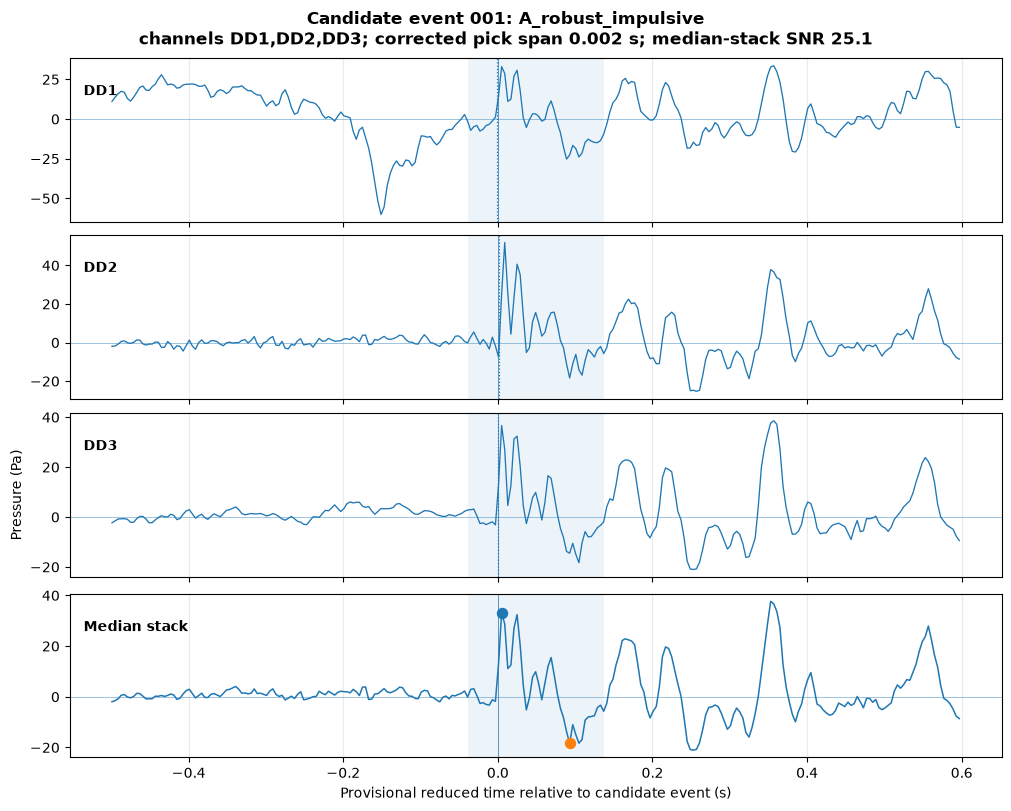

In [12]:
display(
    candidate_events[
        [
            "candidate_event_number",
            "reduced_event_time",
            "channels",
            "corrected_pick_span_s",
            "median_stack_snr",
            "positive_peak_pa",
            "negative_peak_pa",
            "positive_negative_lag_s",
            "event_start_s",
            "event_end_s",
            "quality_class",
            "segment_file",
        ]
    ].head(20)
)

PREVIEW_EVENT_NUMBER = int(
    candidate_events.iloc[0]["candidate_event_number"]
)
preview = build_candidate_event_figure(PREVIEW_EVENT_NUMBER)
plt.show()

## Production outputs

The output paths remain compatible with the downstream planar-array analysis:

```text
outputs/candidate_airwave_preparation/
    event_streams/candidate_event_001.pkl ...
    derived/candidate_airwave_event_catalogue.csv
    derived/candidate_event_pick_assignments.csv
    derived/candidate_event_stream_index.csv
    derived/unassociated_accepted_infrasound_picks.csv
    derived/candidate_event_processing_metadata.json
```
